# 🧠 Sukoon-Scope v2 — Student Stress Level Prediction

**Goal:** predict a student's stress level (**Low / Medium / High**) from psychological, physiological,
environmental, academic and social factors, so a college could flag students who may need support early.

**What changed from v1**

| | v1 | v2 (this notebook) |
|---|---|---|
| Data | 80,000-row habits dataset (stress unrelated to features) | 1,100-row student stress dataset with a learnable 3-class target (audited — see §6) |
| Target | `stress_level > 5` (binary, near-random) | 3-class stress level |
| Evaluation | one train/test split, accuracy only | baseline + repeated CV + untouched hold-out test + bootstrap CI |
| Sanity checks | none | majority baseline, shuffled-label control, learning curve |
| Leakage | `dropout_risk` (derived from stress) was a feature | single-feature audit; suspect feature `blood_pressure` excluded |
| Explainability | impurity importance | permutation importance + feature-group ablation |

**Workflow:** load → audit → EDA → split (test set locked away) → **leakage audit** → compare models with CV → tune →
evaluate **once** on the test set → error analysis → explain → save model.

## 1. Setup

In [1]:
import json, warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, f1_score)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold,
                                     cross_val_score, cross_validate, learning_curve,
                                     train_test_split)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
for d in ("data", "figures", "models"):
    Path(d).mkdir(exist_ok=True)

LABELS = {0: "Low", 1: "Medium", 2: "High"}
print("Setup complete.")

Setup complete.


## 2. Load the data

The loader tries, in order: a local file in `data/` → Kaggle (`kagglehub`) → a public GitHub mirror →
a manual upload prompt (Colab). The Kaggle dataset is
[`rxnach/student-stress-factors-a-comprehensive-analysis`](https://www.kaggle.com/datasets/rxnach/student-stress-factors-a-comprehensive-analysis)
— check its page for licence terms.

In [2]:
DATA_PATH = Path("data/StressLevelDataset.csv")
MIRROR_URL = ("https://raw.githubusercontent.com/AtefeAsadi/Academic-Stress-Student-/"
              "main/data/StressLevelDataset.csv")

def load_dataset():
    if DATA_PATH.exists():
        return pd.read_csv(DATA_PATH), "local file"
    try:                                                      # 1) Kaggle
        import kagglehub
        folder = kagglehub.dataset_download("rxnach/student-stress-factors-a-comprehensive-analysis")
        df = pd.read_csv(next(Path(folder).rglob("StressLevelDataset.csv")))
        df.to_csv(DATA_PATH, index=False)
        return df, "Kaggle (kagglehub)"
    except Exception as e:
        print(f"Kaggle download skipped ({type(e).__name__}).")
    try:                                                      # 2) GitHub mirror
        df = pd.read_csv(MIRROR_URL)
        df.to_csv(DATA_PATH, index=False)
        return df, "GitHub mirror"
    except Exception as e:
        print(f"GitHub mirror skipped ({type(e).__name__}).")
    try:                                                      # 3) manual upload in Colab
        from google.colab import files
        print("Upload StressLevelDataset.csv:")
        name = next(iter(files.upload()))
        df = pd.read_csv(name)
        df.to_csv(DATA_PATH, index=False)
        return df, "manual upload"
    except ImportError:
        raise FileNotFoundError("Put StressLevelDataset.csv in the data/ folder and re-run.")

df, source = load_dataset()
print(f"Loaded from: {source}  |  shape = {df.shape}")
assert "stress_level" in df.columns, "Unexpected file: 'stress_level' column not found"
df.head()

Kaggle download skipped (ModuleNotFoundError).
Loaded from: GitHub mirror  |  shape = (1100, 21)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


## 3. Data audit

Before modelling: missing values, duplicates, value ranges, class balance.
The 20 features fall into the five groups used by the dataset's authors (used later for the ablation study).

In [3]:
print("Missing values :", int(df.isna().sum().sum()))
print("Duplicate rows :", int(df.duplicated().sum()))
print("All numeric    :", bool((df.dtypes != "object").all()))
print("\nClass balance (stress_level):")
print(df["stress_level"].value_counts().sort_index().rename(LABELS).to_frame("count")
        .assign(share=lambda t: (t["count"] / len(df)).round(3)))
print("\nValue ranges:")
display(df.describe().T[["min", "max", "mean"]].round(2))

FEATURE_GROUPS = {
    "Psychological":  ["anxiety_level", "self_esteem", "mental_health_history", "depression"],
    "Physiological":  ["headache", "blood_pressure", "sleep_quality", "breathing_problem"],
    "Environmental":  ["noise_level", "living_conditions", "safety", "basic_needs"],
    "Academic":       ["academic_performance", "study_load", "teacher_student_relationship",
                       "future_career_concerns"],
    "Social":         ["social_support", "peer_pressure", "extracurricular_activities", "bullying"],
}
assert sorted(sum(FEATURE_GROUPS.values(), [])) == sorted(c for c in df.columns if c != "stress_level")

Missing values : 0
Duplicate rows : 0
All numeric    : True

Class balance (stress_level):
              count  share
stress_level              
Low             373  0.339
Medium          358  0.325
High            369  0.335

Value ranges:


,min,max,mean
anxiety_level,0.0,21.0,11.06
self_esteem,0.0,30.0,17.78
mental_health_history,0.0,1.0,0.49
depression,0.0,27.0,12.56
headache,0.0,5.0,2.51
blood_pressure,1.0,3.0,2.18
sleep_quality,0.0,5.0,2.66
breathing_problem,0.0,5.0,2.75
noise_level,0.0,5.0,2.65
living_conditions,0.0,5.0,2.52


## 4. Exploratory analysis

Three questions: is the target balanced, which features move with stress, and are features redundant with each other?

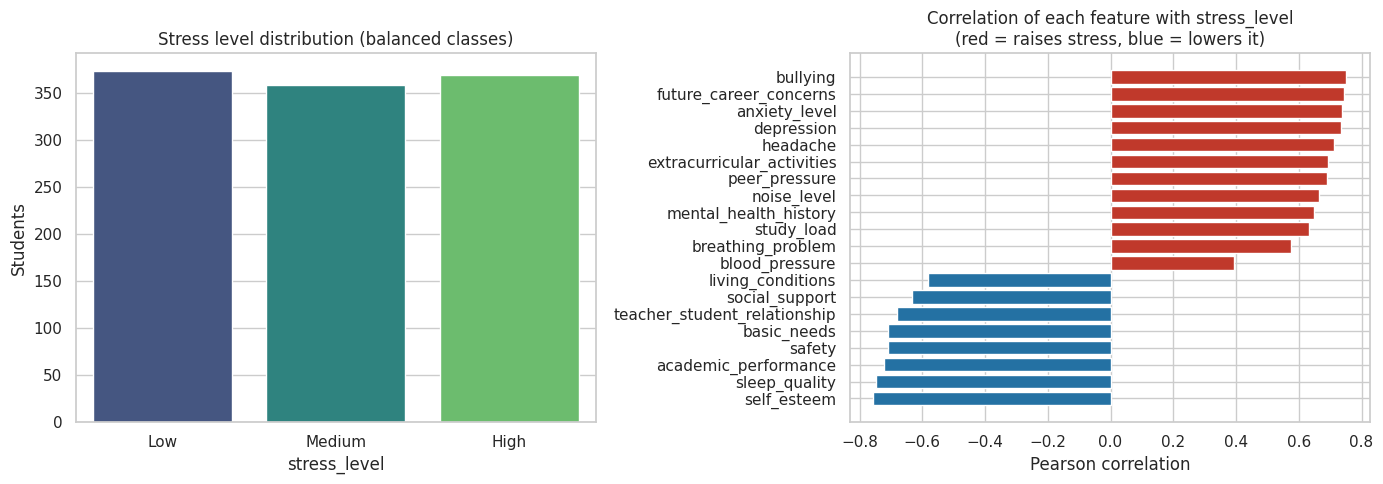

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

counts = df["stress_level"].map(LABELS).value_counts().reindex(["Low", "Medium", "High"])
sns.barplot(x=counts.index, y=counts.values, palette="viridis", ax=ax[0])
ax[0].set_title("Stress level distribution (balanced classes)")
ax[0].set_ylabel("Students")

corr = df.corr()["stress_level"].drop("stress_level").sort_values()
colors = ["#c0392b" if v > 0 else "#2471a3" for v in corr]
ax[1].barh(corr.index, corr.values, color=colors)
ax[1].set_title("Correlation of each feature with stress_level\n(red = raises stress, blue = lowers it)")
ax[1].set_xlabel("Pearson correlation")
plt.tight_layout()
plt.savefig("figures/01_target_and_correlations.png", dpi=150)
plt.show()

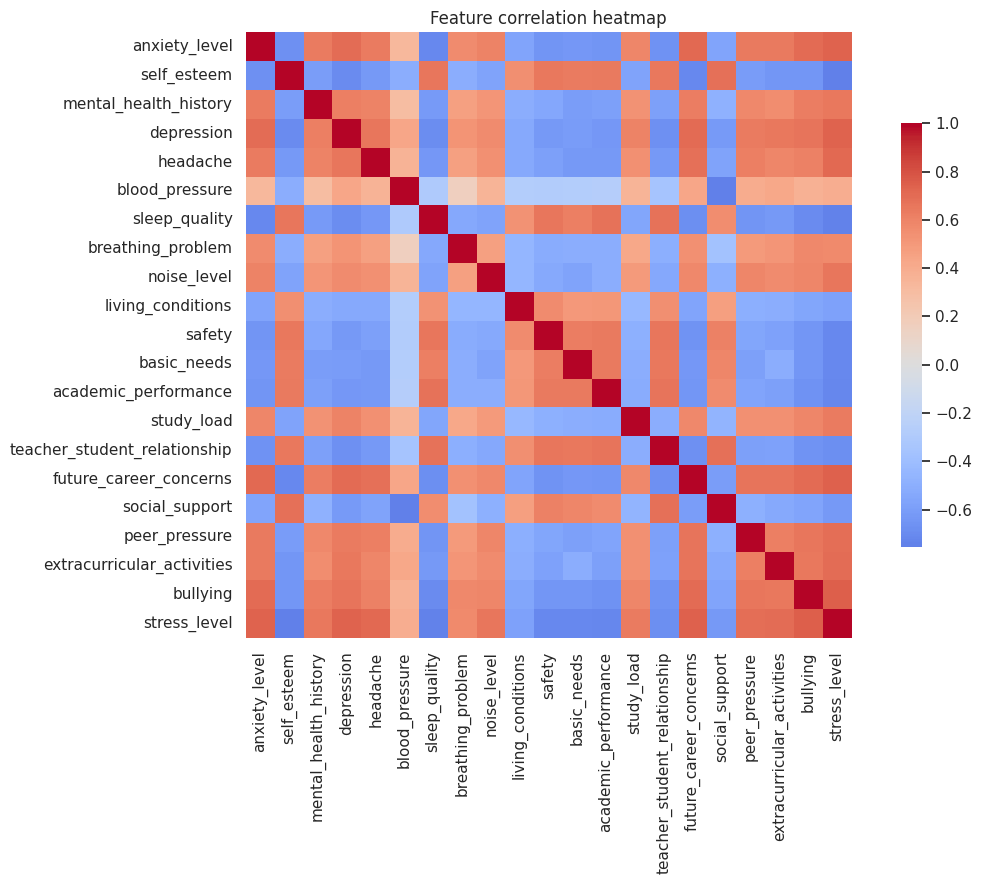

In [5]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=False, square=True, cbar_kws={"shrink": .7})
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.savefig("figures/02_correlation_heatmap.png", dpi=150)
plt.show()

**Reading the plots:** correlations with stress are strong (up to ~0.75 in magnitude) and many features are correlated
with each other. That is good for prediction but has two consequences we handle later:
(1) a **simple linear model should already do well**, and (2) **importance is shared** between correlated features,
so we use permutation importance and group-level ablation rather than trusting a single ranking.

## 5. Train / test split

The test set (20 %, stratified) is **locked away** now. All model selection and tuning use only the training set,
via repeated stratified cross-validation. The test set is used **once**, at the end.

In [6]:
X = df.drop(columns="stress_level")
y = df["stress_level"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)   # 15 fits per model

Train: (880, 20)   Test: (220, 20)


## 6. Leakage & artefact audit (training data only)

High accuracy is only good news if it is *earned*. Two quick checks:

1. **Single-feature test** — how well does each feature predict stress *on its own*? A physiological measurement that
   nearly determines the label deserves suspicion.
2. **Cross-tab of the top suspect** against the target.

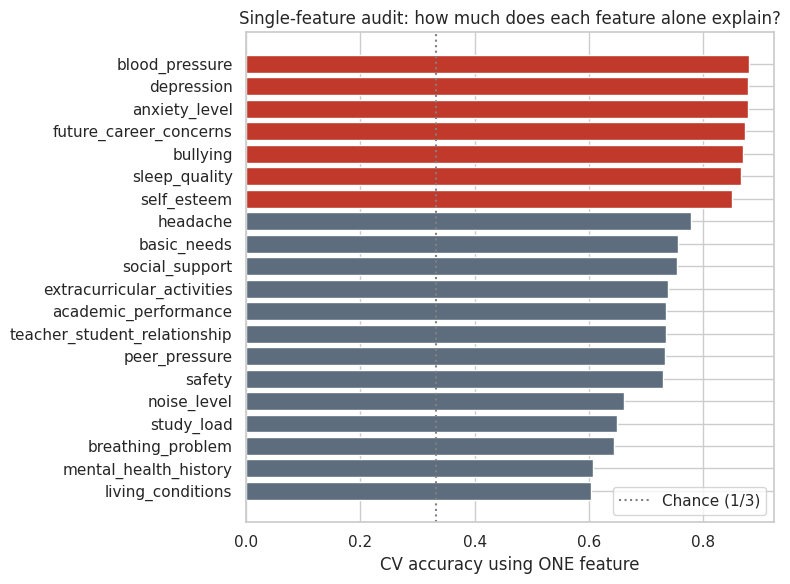

blood_pressure vs stress level (training rows):


stress_level,High,Low,Medium
blood_pressure,,,
1,0,0,236
2,0,243,0
3,295,56,50


In [7]:
rf_single = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1)   # trees can use coded values
single = pd.Series({c: cross_val_score(rf_single, X_train[[c]], y_train, cv=cv, n_jobs=-1).mean()
                    for c in X_train.columns}).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(single.index, single.values, color=["#c0392b" if v > 0.8 else "#5d6d7e" for v in single.values])
plt.axvline(1 / 3, color="gray", ls=":", label="Chance (1/3)")
plt.xlabel("CV accuracy using ONE feature"); plt.legend()
plt.title("Single-feature audit: how much does each feature alone explain?")
plt.tight_layout()
plt.savefig("figures/03_single_feature_audit.png", dpi=150)
plt.show()

print("blood_pressure vs stress level (training rows):")
display(pd.crosstab(X_train["blood_pressure"], y_train.map(LABELS)))

**What the audit shows**

* `blood_pressure` (values 1, 2, 3) predicts stress about as well as *all 20 features together*. Two of its three values
  map to exactly one stress class — a pattern a real physiological measurement would not produce. It behaves like a
  code derived from the label.
* Several other features (anxiety, depression, career worries, bullying, sleep) *each* reach ~85-88 % **alone**, yet
  combining all 20 barely improves on that. Independent real-world signals would add up; here they are redundant copies
  of the same information, which suggests a **ceiling set by the labels**, not by our models.

**Decision:** treat `blood_pressure` as a leakage suspect and **exclude it** from the main pipeline (flag below to
re-include it). We also lower our expectations: this dataset is fine for demonstrating a rigorous ML workflow, but its
accuracy should not be quoted as real-world performance.

In [8]:
SUSPECT_FEATURES = ["blood_pressure"]
DROP_SUSPECT = True                      # set False to reproduce the "all 20 features" run

lr_check = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
with_bp = cross_val_score(lr_check, X_train, y_train, cv=cv, n_jobs=-1).mean()
no_bp = cross_val_score(lr_check, X_train.drop(columns=SUSPECT_FEATURES), y_train, cv=cv, n_jobs=-1).mean()
print(f"Logistic Regression CV accuracy - all 20 features : {with_bp:.3f}")
print(f"Logistic Regression CV accuracy - without suspect : {no_bp:.3f}   (cost of removing it: {with_bp - no_bp:+.3f})")

FEATURES = [c for c in X.columns if not (DROP_SUSPECT and c in SUSPECT_FEATURES)]
X, X_train, X_test = X[FEATURES], X_train[FEATURES], X_test[FEATURES]
FEATURE_GROUPS = {g: [c for c in cols if c in FEATURES] for g, cols in FEATURE_GROUPS.items()}
print(f"\nModelling with {len(FEATURES)} features.")

Logistic Regression CV accuracy - all 20 features : 0.880
Logistic Regression CV accuracy - without suspect : 0.872   (cost of removing it: +0.008)

Modelling with 19 features.


## 7. Compare models (training data only, 5-fold × 3 repeats)

Seven model families, plus:
* a **majority-class baseline** — the score you get by doing nothing;
* a **shuffled-label control** — the same model trained on randomly permuted targets. If it scores about the same as the
  baseline, the real scores above it can only come from genuine signal.

,model,accuracy,acc_std,macro_f1
0,Hist. Gradient Boosting,0.881,0.032,0.881
1,XGBoost,0.878,0.023,0.878
2,Random Forest,0.872,0.027,0.872
3,Logistic Regression,0.872,0.028,0.871
4,MLP (neural net),0.868,0.031,0.868
5,LDA,0.865,0.029,0.865
6,SVM (RBF),0.865,0.027,0.865
7,Control: LogReg on SHUFFLED labels,0.366,0.044,NaN
8,Majority baseline,0.340,0.002,0.169


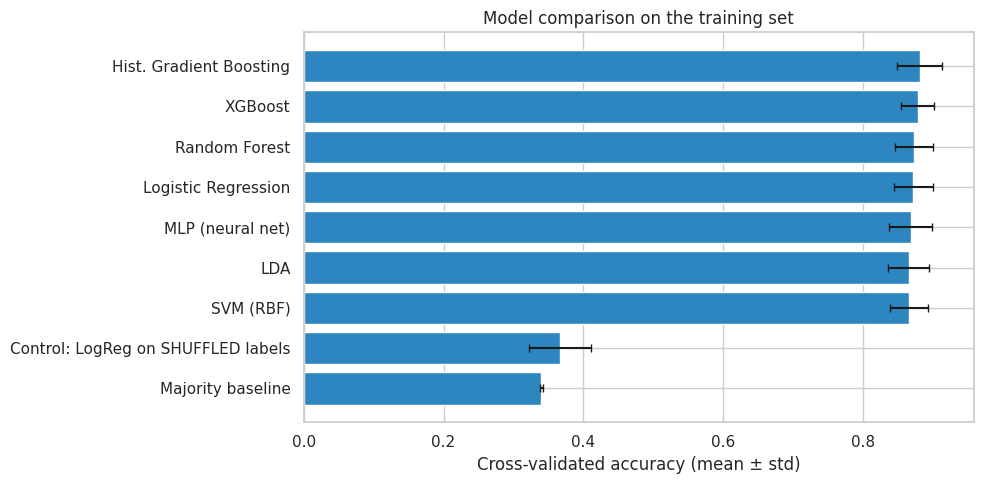

In [9]:
models = {
    "Majority baseline":   DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "LDA":                 make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC()),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Hist. Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED),
    "MLP (neural net)":    make_pipeline(StandardScaler(),
                                         MLPClassifier((32,), alpha=1e-2, max_iter=2000, random_state=SEED)),
}
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
                                      colsample_bytree=0.8, random_state=SEED, n_jobs=1)
except ImportError:
    print("xgboost not installed - skipping it (pip install xgboost to include).")

rows = []
for name, model in models.items():
    r = cross_validate(model, X_train, y_train, cv=cv, n_jobs=-1,
                       scoring={"acc": "accuracy", "f1": "f1_macro"})
    rows.append({"model": name, "accuracy": r["test_acc"].mean(), "acc_std": r["test_acc"].std(),
                 "macro_f1": r["test_f1"].mean()})

# shuffled-label control (uses the strongest simple model)
rng = np.random.default_rng(SEED)
y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)
ctrl = cross_val_score(models["Logistic Regression"], X_train, y_shuffled, cv=cv, n_jobs=-1)
rows.append({"model": "Control: LogReg on SHUFFLED labels", "accuracy": ctrl.mean(),
             "acc_std": ctrl.std(), "macro_f1": np.nan})

results = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
display(results.round(3))

plt.figure(figsize=(10, 5))
plot_df = results.sort_values("accuracy")
plt.barh(plot_df["model"], plot_df["accuracy"], xerr=plot_df["acc_std"], color="#2e86c1", capsize=3)
plt.xlabel("Cross-validated accuracy (mean ± std)")
plt.title("Model comparison on the training set")
plt.tight_layout()
plt.savefig("figures/04_model_comparison.png", dpi=150)
plt.show()

**How to read this:** the baseline (~1/3) and the shuffled-label control show what "no signal" looks like.
Every real model is far above them. Compare the models' gaps with the ± std: when differences are smaller than the
noise, model choice is not what limits accuracy — the data is. In that situation a simple, interpretable model is the
sensible choice.

## 8. Hyper-parameter tuning

Tune the two most promising families, still using training data only. The winner is chosen by **cross-validated**
score — never by looking at the test set.

In [10]:
cv_tune = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

lr_search = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    param_grid={"logisticregression__C": np.logspace(-4, 2, 13)},
    cv=cv_tune, scoring="accuracy", n_jobs=-1).fit(X_train, y_train)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions={"n_estimators": [200, 400, 600], "max_depth": [None, 5, 10, 20],
                         "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2", 0.5]},
    n_iter=20, cv=cv_tune, scoring="accuracy", random_state=SEED, n_jobs=-1).fit(X_train, y_train)

c_table = pd.DataFrame({"C": lr_search.cv_results_["param_logisticregression__C"].astype(float),
                        "cv_accuracy": lr_search.cv_results_["mean_test_score"]})
display(c_table.round(4).T)
sane = c_table[c_table.C >= 1e-3].cv_accuracy
print(f"For C >= 0.001 the CV accuracy varies by only {sane.max() - sane.min():.3f}; "
      f"much smaller C (over-regularised) collapses to {c_table.cv_accuracy.min():.3f}.")
print(f"Logistic Regression  best CV acc = {lr_search.best_score_:.3f}   C = {lr_search.best_params_['logisticregression__C']:.4g}")
print(f"Random Forest        best CV acc = {rf_search.best_score_:.3f}   params = {rf_search.best_params_}")

best_search = max([("Logistic Regression", lr_search), ("Random Forest", rf_search)],
                  key=lambda t: t[1].best_score_)
final_name, final_model = best_search[0], best_search[1].best_estimator_
print(f"\nSelected model (by CV score): {final_name}")

,0,1,2,3,4,5,6,7,8,9,10,11,12
C,0.0001,0.0003,0.0010,0.0032,0.0100,0.0316,0.1000,0.3162,1.0000,3.1623,10.0000,31.6228,100.0000
cv_accuracy,0.6614,0.8608,0.8812,0.8761,0.8705,0.8676,0.8705,0.8716,0.8716,0.8722,0.8722,0.8722,0.8722


For C >= 0.001 the CV accuracy varies by only 0.014; much smaller C (over-regularised) collapses to 0.661.
Logistic Regression  best CV acc = 0.881   C = 0.001
Random Forest        best CV acc = 0.877   params = {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 10}

Selected model (by CV score): Logistic Regression


## 9. Final evaluation on the untouched test set

This is the number to report. Because the test set is small (220 rows), we also give a **bootstrap 95 % confidence
interval** — the honest way to say "the true accuracy is probably within this range".

Test accuracy : 0.864   (95% bootstrap CI: 0.818 - 0.909)
Test macro-F1 : 0.864
Majority baseline on the same test set: 0.336

              precision    recall  f1-score   support

         Low      0.923     0.811     0.863        74
      Medium      0.788     0.931     0.854        72
        High      0.900     0.851     0.875        74

    accuracy                          0.864       220
   macro avg      0.870     0.864     0.864       220
weighted avg      0.871     0.864     0.864       220



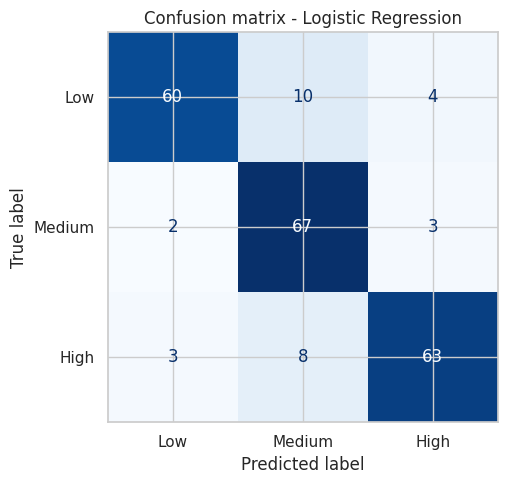

In [11]:
y_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")
baseline_acc = accuracy_score(y_test, DummyClassifier(strategy="most_frequent")
                              .fit(X_train, y_train).predict(X_test))

# bootstrap CI on test accuracy
rng = np.random.default_rng(SEED)
correct = (y_pred == y_test.values).astype(int)
boot = [rng.choice(correct, size=len(correct), replace=True).mean() for _ in range(5000)]
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print(f"Test accuracy : {test_acc:.3f}   (95% bootstrap CI: {ci_low:.3f} - {ci_high:.3f})")
print(f"Test macro-F1 : {test_f1:.3f}")
print(f"Majority baseline on the same test set: {baseline_acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=list(LABELS.values()), digits=3))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=list(LABELS.values()),
                                        cmap="Blues", ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix - {final_name}")
plt.tight_layout()
plt.savefig("figures/05_confusion_matrix.png", dpi=150)
plt.show()

## 10. Error analysis

Stress is **ordinal** (Low < Medium < High). A mistake between neighbouring levels is far less harmful than calling a
High-stress student Low. Let's see which kind of mistake the model makes.

In [12]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

def error_profile(y_true, y_hat):
    m = confusion_matrix(y_true, y_hat)
    errs = m.sum() - np.trace(m)
    adj = sum(m[i, j] for i in range(3) for j in range(3) if abs(i - j) == 1)
    return m, errs, adj, m[0, 2] + m[2, 0], m[2, 0]

# the test set is small (220), so also look at out-of-fold predictions on the 880 training rows
p_cv = cross_val_predict(clone(final_model), X_train, y_train, cv=StratifiedKFold(10, shuffle=True, random_state=SEED))
for name, (yt, yh) in {"Test set (n=220)": (y_test, y_pred), "Out-of-fold train (n=880)": (y_train, p_cv)}.items():
    m, errs, adj, severe, high_missed = error_profile(yt, yh)
    print(f"{name}: {errs} errors | neighbouring levels {adj / errs:.0%} | Low<->High swaps {severe} "
          f"({severe / errs:.0%}) | High predicted Low: {high_missed} of {m[2].sum()}")

cm, errors, adjacent, severe, high_missed = error_profile(y_test, y_pred)
_, e_cv, adj_cv, severe_cv, _ = error_profile(y_train, p_cv)

Test set (n=220): 30 errors | neighbouring levels 77% | Low<->High swaps 7 (23%) | High predicted Low: 3 of 74
Out-of-fold train (n=880): 108 errors | neighbouring levels 79% | Low<->High swaps 23 (21%) | High predicted Low: 8 of 295


## 11. Is more data or a bigger model going to help? (learning curve)

If training and validation curves converge and flatten, extra data won't help much and the remaining error is mostly
label noise / subjective self-reporting rather than a weak model.

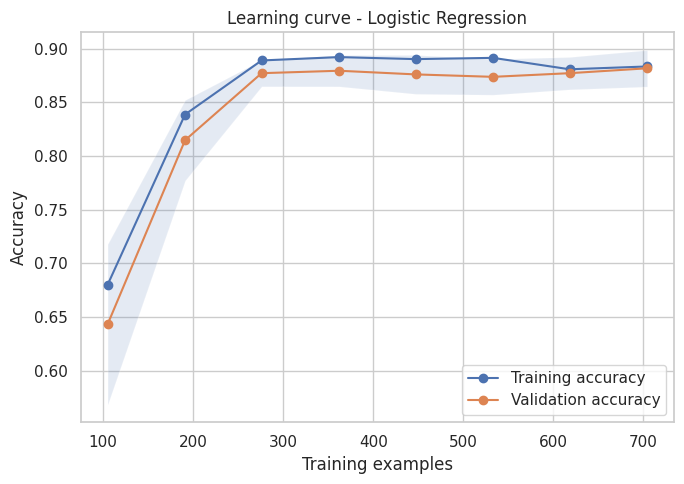

In [13]:
sizes, tr, va = learning_curve(clone(final_model), X_train, y_train, cv=5,
                               train_sizes=np.linspace(0.15, 1.0, 8), scoring="accuracy",
                               n_jobs=-1, random_state=SEED)
plt.figure(figsize=(7, 5))
plt.plot(sizes, tr.mean(1), "o-", label="Training accuracy")
plt.plot(sizes, va.mean(1), "o-", label="Validation accuracy")
plt.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.15)
plt.xlabel("Training examples"); plt.ylabel("Accuracy"); plt.legend()
plt.title(f"Learning curve - {final_name}")
plt.tight_layout()
plt.savefig("figures/06_learning_curve.png", dpi=150)
plt.show()

## 12. Explainability

**Permutation importance** on the test set: shuffle one column and measure how much accuracy drops. Unlike the
impurity-based importance used in v1, it is computed on held-out data and isn't biased toward continuous features.

,feature,drop_in_accuracy,std
4,headache,0.0086,0.0041
7,noise_level,0.0083,0.0044
5,sleep_quality,0.0080,0.0019
8,living_conditions,0.0074,0.0036
1,self_esteem,0.0070,0.0062
9,safety,0.0064,0.0049
15,social_support,0.0059,0.0049
14,future_career_concerns,0.0058,0.0048
12,study_load,0.0050,0.0044
17,extracurricular_activities,0.0045,0.0047


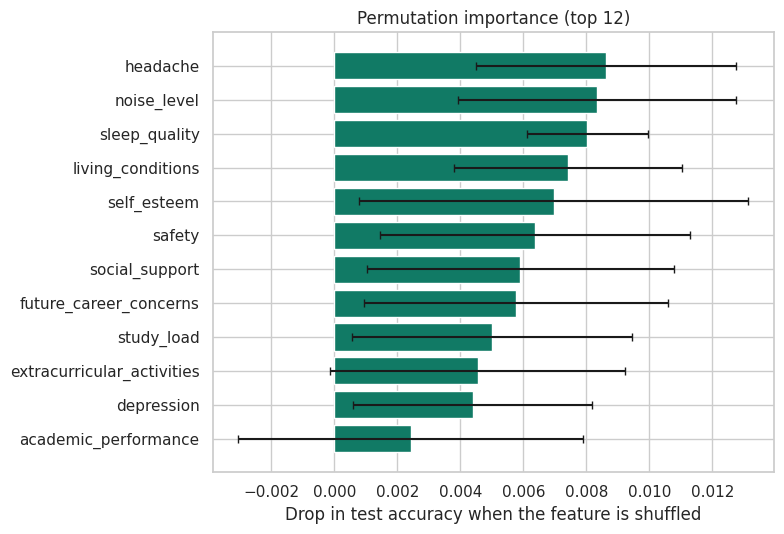

In [14]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=30, random_state=SEED,
                              scoring="accuracy", n_jobs=-1)
imp = (pd.DataFrame({"feature": X.columns, "drop_in_accuracy": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("drop_in_accuracy", ascending=False))
display(imp.head(10).round(4))

top = imp.head(12).iloc[::-1]
plt.figure(figsize=(8, 5.5))
plt.barh(top["feature"], top["drop_in_accuracy"], xerr=top["std"], color="#117a65", capsize=3)
plt.xlabel("Drop in test accuracy when the feature is shuffled")
plt.title("Permutation importance (top 12)")
plt.tight_layout()
plt.savefig("figures/07_permutation_importance.png", dpi=150)
plt.show()

**Reading it:** each individual drop is small (typically under one point) because correlated features cover for one
another when a single column is shuffled. Treat the ranking as weak evidence about *which* features matter, and prefer the
group-level view below.

### Feature-group ablation

Some features (e.g. `headache`, `anxiety_level`) may be *symptoms* of stress rather than causes. A university can't
"intervene" on a headache, but it can act on workload, bullying or living conditions. So we ask: how well can each group
predict stress **on its own**, and how much is lost **when it is removed**?

All 20 features: 0.881


,only_this_group,all_except_group
group,,
Psychological,0.695,0.868
Physiological,0.646,0.881
Environmental,0.722,0.876
Academic,0.736,0.876
Social,0.666,0.875


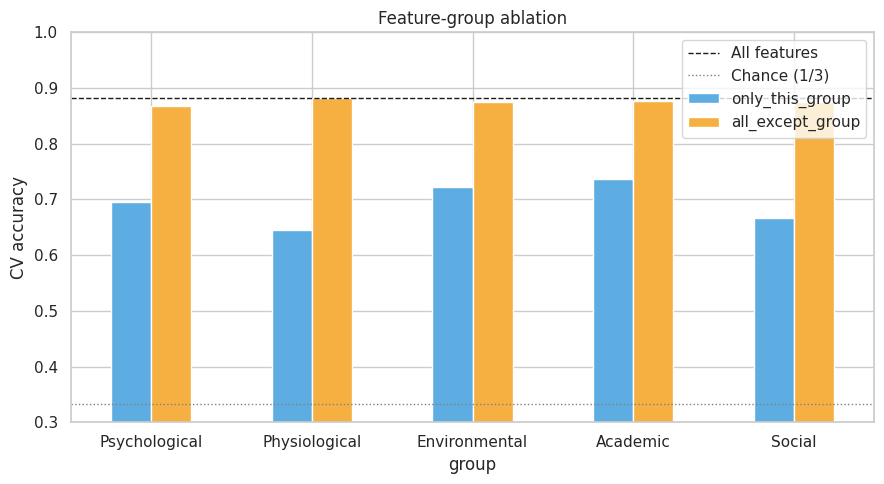

In [15]:
cv_fast = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)
base = cross_val_score(clone(final_model), X_train, y_train, cv=cv_fast, n_jobs=-1).mean()

rows = []
for group, cols in FEATURE_GROUPS.items():
    only = cross_val_score(clone(final_model), X_train[cols], y_train, cv=cv_fast, n_jobs=-1).mean()
    without = cross_val_score(clone(final_model), X_train.drop(columns=cols), y_train, cv=cv_fast, n_jobs=-1).mean()
    rows.append({"group": group, "only_this_group": only, "all_except_group": without})
abl = pd.DataFrame(rows).set_index("group")
print(f"All 20 features: {base:.3f}")
display(abl.round(3))

ax = abl.plot(kind="bar", figsize=(9, 5), rot=0, color=["#5dade2", "#f5b041"])
ax.axhline(base, color="k", ls="--", lw=1, label="All features")
ax.axhline(1 / 3, color="gray", ls=":", lw=1, label="Chance (1/3)")
ax.set_ylim(0.3, 1.0); ax.set_ylabel("CV accuracy"); ax.legend()
ax.set_title("Feature-group ablation")
plt.tight_layout()
plt.savefig("figures/08_group_ablation.png", dpi=150)
plt.show()

**Reading it:** because the features are redundant (see §6), removing one group barely changes accuracy, so the
*"all except group"* column **cannot** be used to argue a group is unimportant. The *"only this group"* column is the
informative one: it shows how much each group can explain by itself. Groups an institution can act on
(environmental, academic, social) can be compared with the psychological/physiological *symptom* groups.

## 13. Save the model and predict for a new student

The saved file is a scikit-learn pipeline (scaler + model), so it accepts raw feature values.

In [16]:
joblib.dump(final_model, "models/stress_model.joblib")
Path("models/feature_order.json").write_text(json.dumps(list(X.columns)))
print("Saved models/stress_model.joblib")

def predict_stress(student: dict, model_path="models/stress_model.joblib"):
    model = joblib.load(model_path)
    order = json.loads(Path("models/feature_order.json").read_text())
    row = pd.DataFrame([student])[order]
    proba = model.predict_proba(row)[0]
    return {"predicted_level": LABELS[int(model.predict(row)[0])],
            "probabilities": {LABELS[i]: round(float(p), 3) for i, p in enumerate(proba)}}

# demo: one real test-set student from each class
for cls in (0, 1, 2):
    sample = X_test[y_test == cls].iloc[0].to_dict()
    print(f"True: {LABELS[cls]:6s} ->", predict_stress(sample))

Saved models/stress_model.joblib
True: Low    -> {'predicted_level': 'Low', 'probabilities': {'Low': 0.726, 'Medium': 0.237, 'High': 0.038}}
True: Medium -> {'predicted_level': 'Medium', 'probabilities': {'Low': 0.28, 'Medium': 0.445, 'High': 0.275}}
True: High   -> {'predicted_level': 'High', 'probabilities': {'Low': 0.042, 'Medium': 0.229, 'High': 0.73}}


## 14. Results summary

In [17]:
from IPython.display import Markdown, display
best_cv = max(lr_search.best_score_, rf_search.best_score_)
display(Markdown(f'''
| Metric | Value |
|---|---|
| Data source | {source} |
| Rows / features used | {df.shape[0]} / {len(FEATURES)} |
| Majority baseline (test) | **{baseline_acc:.1%}** |
| Selected model | **{final_name}** |
| Cross-validated accuracy (train; slightly optimistic, C was picked on these folds) | {best_cv:.1%} |
| **Test accuracy** | **{test_acc:.1%}** (95% CI {ci_low:.1%} - {ci_high:.1%}) |
| Test macro-F1 | {test_f1:.3f} |
| Errors that are Low <-> High swaps (test / out-of-fold) | {severe / errors:.0%} / {severe_cv / e_cv:.0%} |
| High-stress students predicted Low (test) | {high_missed} of {cm[2].sum()} |
'''))


| Metric | Value |
|---|---|
| Data source | GitHub mirror |
| Rows / features used | 1100 / 19 |
| Majority baseline (test) | **33.6%** |
| Selected model | **Logistic Regression** |
| Cross-validated accuracy (train; slightly optimistic, C was picked on these folds) | 88.1% |
| **Test accuracy** | **86.4%** (95% CI 81.8% - 90.9%) |
| Test macro-F1 | 0.864 |
| Errors that are Low <-> High swaps (test / out-of-fold) | 23% / 21% |
| High-stress students predicted Low (test) | 3 of 74 |


## 15. Conclusions & limitations

**Conclusions**
* The features carry real, learnable signal: every model is far above the majority baseline and the shuffled-label
  control, a big change from v1 where the best model was barely above the baseline.
* Model choice matters little: model families are separated by less than their cross-validation noise, so a tuned linear
  model is a sensible, interpretable choice.
* Most mistakes are between **neighbouring** levels (roughly three-quarters in both the test set and out-of-fold
  predictions); Low ↔ High swaps are the minority (§10). Note the earlier version, which still contained
  `blood_pressure`, had far more Low ↔ High swaps — the suspect feature was distorting the linear model as well as
  inflating accuracy.

**Limitations — say these out loud in an interview**
* **Signs of generated data.** One feature (`blood_pressure`) nearly determines the label, and many features alone match
  the accuracy of all of them together. That points to a dataset built around the label with a fixed noise level. The
  ~87-88 % here shows the *pipeline* works; it is **not** evidence of real-world performance.
* **Small sample (1,100).** The test set has 220 rows, so the confidence interval spans roughly ±4-5 points.
* **Symptoms vs causes.** Several features are consequences of stress. This is a *predictive* model, not a causal one:
  do not claim that changing a feature would reduce stress.
* **Not a clinical tool.** It should support, never replace, human counselling; keep a person in the loop and protect
  student privacy and consent.

**Next steps:** re-validate on a genuinely collected survey (e.g. the 843-row *Stress and Well-being Data of College
Students* on Kaggle — not tested here); add calibrated probabilities and a threshold that prioritises recall on the High
class; add SHAP for per-student explanations; wrap `predict_stress` in a Streamlit form.